<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/Chapter_10_01%ED%95%AD%EB%AA%A9%EC%97%90_%EB%94%B0%EB%A5%B8_%EC%9E%90%EB%8F%99%EC%B0%A8%EC%97%B0%EB%B9%84_%EC%98%88%EC%B8%A1%ED%95%98%EA%B8%B0_2026_03_29.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10장. 회귀분석 (1) 자동차 연비 예측 분석

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


# 4. 데이터 준비 및 탐색

In [3]:
import numpy as np
import pandas as pd

data_df = pd.read_csv('/content/auto-mpg.csv', header = 0, engine = 'python')

In [4]:
print('데이터셋 크기: ', data_df.shape)
data_df.head()

데이터셋 크기:  (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
data_df = data_df.drop(['car_name', 'origin', 'horsepower'], axis = 1, inplace = False)
data_df.head()  #작업 확인용 출력

,mpg,cylinders,displacement,weight,acceleration,model_year
0,18.0,8,307.0,3504,12.0,70
1,15.0,8,350.0,3693,11.5,70
2,18.0,8,318.0,3436,11.0,70
3,16.0,8,304.0,3433,12.0,70
4,17.0,8,302.0,3449,10.5,70


In [6]:
print('데이터셋 크기: ', data_df.shape)

데이터셋 크기:  (398, 6)


In [7]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 18.8 KB


# 5. 분석 모델 구축, 결과 분석 및 시각화
## 5.1 선형 회귀 분석 모델 구축하기

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
#X, Y 분할하기
Y = data_df['mpg']
X = data_df.drop(['mpg'], axis = 1, inplace = False)

In [10]:
#훈련용 데이터와 평가용 데이터 분할하기
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0)

In [11]:
#선형 회귀 분석 : 모델 생성
lr = LinearRegression()

In [12]:
#선형 회귀 분석 : 모델 훈련
lr.fit(X_train.values, Y_train)

LinearRegression()

In [13]:
#선형 회귀 분석 : 평가 데이터에 대한 예측 수행 -> 예측 결과 Y_predict 구하기
Y_predict = lr.predict(X_test.values)

### - 평가 지표를 사용하여 선형 회귀 분석 모델 평가하기

In [14]:
mse = mean_squared_error(Y_test, Y_predict)
rmse = np.sqrt(mse)
print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('R^2(Variance score) : {0:.3f}'.format(r2_score(Y_test, Y_predict)))

MSE : 12.278, RMSE : 3.504
R^2(Variance score) : 0.808


### - 각 피처의 회귀 계수 확인

In [15]:
print('Y 절편 값: ', np.round(lr.intercept_, 2))
print('회귀 계수 값: ', np.round(lr.coef_, 2))

Y 절편 값:  -17.55
회귀 계수 값:  [-0.14  0.01 -0.01  0.2   0.76]


In [16]:
coef = pd.Series(data = np.round(lr.coef_, 2), index = X.columns)
coef.sort_values(ascending = False)

,0
model_year,0.76
acceleration,0.20
displacement,0.01
weight,-0.01
cylinders,-0.14


## 5.2 회귀 분석 결과를 산점도 + 선형 회귀 그래프로 시각화하기

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

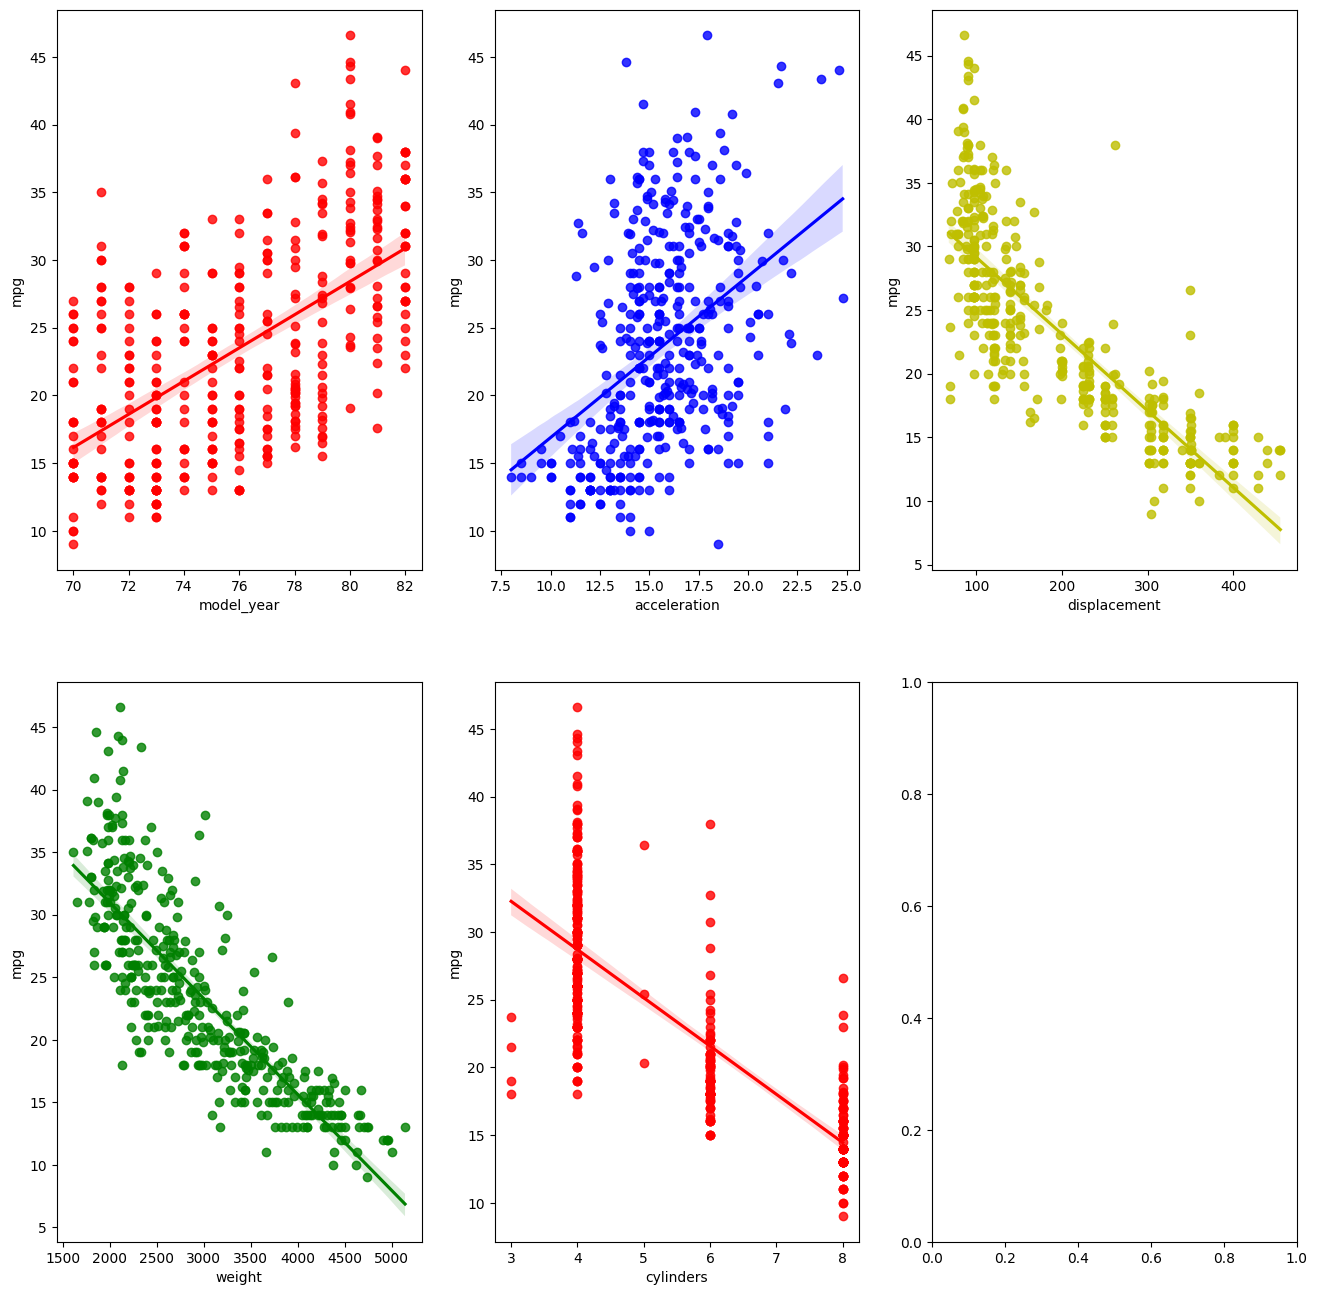

In [23]:
fig, axs = plt.subplots(figsize = (16, 16), nrows = 2, ncols = 3)
x_features = ['model_year', 'acceleration', 'displacement', 'weight', 'cylinders']
plot_color = ['r', 'b', 'y', 'g', 'r']
for i, feature in enumerate(x_features):
    row = int(i/3)
    col = i%3
    sns.regplot(x = feature, y = 'mpg', data = data_df, ax = axs[row][col], color = plot_color[i])

### 연비 예측하기

In [24]:
print("연비를 예측하고 싶은 차의 정보를 입력해주세요.")

cylinders = int(input("cylinders : "))
displacement = float(input("displacement : "))
weight = int(input("weight : "))
acceleration = float(input("acceleration : "))
model_year = int(input("model_year : "))

연비를 예측하고 싶은 차의 정보를 입력해주세요.
cylinders : 6
displacement : 200
weight : 3500
acceleration : 15
model_year : 76


In [25]:
mpg_predict = lr.predict([[cylinders, displacement, weight, acceleration, model_year]])

In [26]:
print("이 자동차의 예상 연비(MPG)는 %.2f입니다." % mpg_predict)

이 자동차의 예상 연비(MPG)는 19.59입니다.


/tmp/ipykernel_4139/3712939959.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("이 자동차의 예상 연비(MPG)는 %.2f입니다." % mpg_predict)
